# Veri Madenciliği Uygulamaları — Kapsamlı Colab Notebook

**Hüseyin GÖKALP** — 2540138002 — SDÜ Bilgisayar Mühendisliği Doktora Programı  
**Ders:** 11117BLG016 Veri Madenciliği Uygulamaları — Doç. Dr. Arif KOYUN  
**Tarih:** Nisan 2026

Bu notebook, veri madenciliği dersinin teorik bölümünde ele alınan tüm temel tekniklerin Python ile çalışan uygulamalarını içermektedir. Her hücre bağımsız olarak çalıştırılabilir; tüm notebook `Runtime → Run all` ile uçtan uca çalıştırılmıştır.

## İçindekiler
1. Kurulum ve Veri Yükleme  
2. ID3 Karar Ağacı (Özgün Uygulama)  
3. scikit-learn CART ve Aşırı Uyum Analizi  
4. Gaussian Naive Bayes  
5. SVM — Kernel Karşılaştırması  
6. MLP Yapay Sinir Ağı  
7. Topluluk Yöntemleri  
8. k-En Yakın Komşu  
9. Kümeleme (K-Means, DBSCAN)  
10. Regresyon  
11. Birliktelik Kuralı Madenciliği (Apriori)  
12. Aykırı Değer Tespiti (Isolation Forest)  
13. Model Değerlendirme (ROC, PR, Karışıklık Matrisi)  
14. Öznitelik Önemi ve PCA

## 1. Kurulum ve Veri Yükleme

In [1]:
# Gerekli kütüphaneleri kur (Colab'da genellikle hazır, mlxtend hariç)
!pip install mlxtend -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, make_moons, make_blobs
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, BaggingClassifier, IsolationForest)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             silhouette_score, precision_recall_curve,
                             average_precision_score, accuracy_score)
from sklearn.decomposition import PCA

# Iris veri kümesini yükle (Fisher, 1936)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

print(f'Iris veri kümesi boyutu: {X_iris.shape}')
print(f'Sınıflar: {iris.target_names}')
print(f'Öznitelikler: {iris.feature_names}')
print(f'Eğitim/Test: {len(X_train)}/{len(X_test)}')

Iris veri kümesi boyutu: (150, 4)
Sınıflar: ['setosa' 'versicolor' 'virginica']
Öznitelikler: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Eğitim/Test: 105/45


## 2. ID3 Karar Ağacı — Özgün Uygulama

Shannon entropi ve bilgi kazancına dayanan ID3 algoritmasının sıfırdan implementasyonu. Weather veri kümesi üzerinde çalıştırılmakta, her adımda en yüksek bilgi kazancına sahip öznitelik seçilerek özyinelemeli ağaç oluşturulmaktadır.

**Matematiksel temel:**
$$H(S) = -\sum_{i=1}^{c} p_i \log_2 p_i$$
$$IG(S, A) = H(S) - \sum_{v \in V(A)} \frac{|S_v|}{|S|} H(S_v)$$

In [ ]:
# Hüseyin GÖKALP — ID3 Decision Tree Özgün Implementasyonu
class myDT:
    def readDatasetFromArray(self):
        dataset = [
            ['OUTLOOK','TEMPERATURE','HUMIDITY','WINDY','PLAY'],
            ['sunny','hot','high','FALSE','no'],
            ['sunny','hot','high','TRUE','no'],
            ['overcast','hot','high','FALSE','yes'],
            ['rainy','mild','high','FALSE','yes'],
            ['rainy','cool','normal','FALSE','yes'],
            ['rainy','cool','normal','TRUE','no'],
            ['overcast','cool','normal','TRUE','yes'],
            ['sunny','mild','high','FALSE','no'],
            ['sunny','cool','normal','FALSE','yes'],
            ['rainy','mild','normal','FALSE','yes'],
            ['sunny','mild','normal','TRUE','yes'],
            ['overcast','mild','high','TRUE','yes'],
            ['overcast','hot','normal','FALSE','yes'],
            ['rainy','mild','high','TRUE','no']
        ]
        self.attributeNames = dataset[0][:-1]
        dataset = dataset[1:]
        self.classes = [row[-1] for row in dataset]
        return [row[:-1] for row in dataset], self.classes, self.attributeNames

    def getEntropy(self, p):
        """Shannon entropisi: H(p) = -p * log2(p)"""
        return -p * math.log2(p) if p != 0 else 0

    def getGain(self, dataset, classes, attribute):
        """Ağırlıklı entropi hesabı — belirli bir öznitelik için"""
        gain, nDataset = 0, len(dataset)
        values = list(set(row[attribute] for row in dataset))
        for value in values:
            newClasses = [classes[i] for i, row in enumerate(dataset)
                          if row[attribute] == value]
            classValues = list(set(newClasses))
            ent = sum(self.getEntropy(newClasses.count(cv)/len(newClasses))
                      for cv in classValues)
            gain += (len(newClasses)/nDataset) * ent
        return gain

    def create_hierarchy(self, data, classes, attrs, maxlevel=-1, level=0):
        """Özyinelemeli ağaç oluşturma"""
        nData, nAttr = len(data), len(attrs)
        newClasses = list(set(classes))
        freq = [classes.count(c) for c in newClasses]
        totalEnt = sum(self.getEntropy(f/nData) for f in freq)
        default = classes[freq.index(max(freq))]
        if nData == 0 or nAttr == 0: return default
        if classes.count(classes[0]) == nData: return classes[0]
        gain = [totalEnt - self.getGain(data, classes, a) for a in range(nAttr)]
        best = gain.index(max(gain))
        tree = {attrs[best]: {}}
        for val in set(row[best] for row in data):
            newData = [row[:best]+row[best+1:] for i,row in enumerate(data)
                       if row[best]==val]
            newCls = [classes[i] for i,row in enumerate(data) if row[best]==val]
            tree[attrs[best]][val] = self.create_hierarchy(
                newData, newCls, attrs[:best]+attrs[best+1:], maxlevel, level+1)
        return tree

    def showHierarchy(self, branch, sep=''):
        if isinstance(branch, dict):
            for key, val in branch.items():
                print(f'{sep}{key}')
                self.showHierarchy(val, sep + '  | ')
        else:
            print(f'{sep} -> ({branch})')

# Çalıştırma
dt = myDT()
data, classes, attrs = dt.readDatasetFromArray()
result = dt.create_hierarchy(data, classes, attrs)
print('=== ID3 Karar Ağacı Hiyerarşisi ===')
dt.showHierarchy(result)

=== ID3 Karar Ağacı Hiyerarşisi ===
OUTLOOK
  | rainy
  |   | WINDY
  |   |   | FALSE
  |   |   |   |  -> (yes)
  |   |   | TRUE
  |   |   |   |  -> (no)
  | sunny
  |   | HUMIDITY
  |   |   | normal
  |   |   |   |  -> (yes)
  |   |   | high
  |   |   |   |  -> (no)
  | overcast
  |   |  -> (yes)


In [ ]:
# Weather verisinde öznitelik bazlı bilgi kazancı hesabı ve görselleştirme
weather_df = pd.DataFrame({
    'Outlook': ['sunny','sunny','overcast','rainy','rainy','rainy','overcast',
                'sunny','sunny','rainy','sunny','overcast','overcast','rainy'],
    'Temperature': ['hot','hot','hot','mild','cool','cool','cool','mild',
                    'cool','mild','mild','mild','hot','mild'],
    'Humidity': ['high','high','high','high','normal','normal','normal','high',
                 'normal','normal','normal','high','normal','high'],
    'Windy': ['FALSE','TRUE','FALSE','FALSE','FALSE','TRUE','TRUE','FALSE',
              'FALSE','FALSE','TRUE','TRUE','FALSE','TRUE'],
    'Play': ['no','no','yes','yes','yes','no','yes','no',
             'yes','yes','yes','yes','yes','no']
})

def entropy(labels):
    n = len(labels)
    if n == 0: return 0
    counts = pd.Series(labels).value_counts()
    probs = counts / n
    return -sum(p * math.log2(p) for p in probs if p > 0)

total_ent = entropy(weather_df['Play'].tolist())
print(f'Toplam Entropi H(S) = {total_ent:.4f} bit\n')

info_gains = {}
for attr in ['Outlook', 'Temperature', 'Humidity', 'Windy']:
    weighted_ent = 0
    for val in weather_df[attr].unique():
        subset = weather_df[weather_df[attr] == val]['Play'].tolist()
        weighted_ent += (len(subset)/len(weather_df)) * entropy(subset)
    info_gains[attr] = total_ent - weighted_ent
    print(f'IG({attr}) = {info_gains[attr]:.4f} bit')

best_attr = max(info_gains, key=info_gains.get)
print(f'\nKök düğüm olarak seçilen öznitelik: {best_attr}')

Toplam Entropi H(S) = 0.9403 bit

IG(Outlook) = 0.2467 bit
IG(Temperature) = 0.0292 bit
IG(Humidity) = 0.1518 bit
IG(Windy) = 0.0481 bit

Kök düğüm olarak seçilen öznitelik: Outlook


## 3. scikit-learn CART ve Aşırı Uyum Analizi

Eğitim Doğruluğu: 0.9905
Test Doğruluğu:   0.8889

Ağaç Kuralları:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- petal width (cm) <= 1.85
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.85
|   |   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



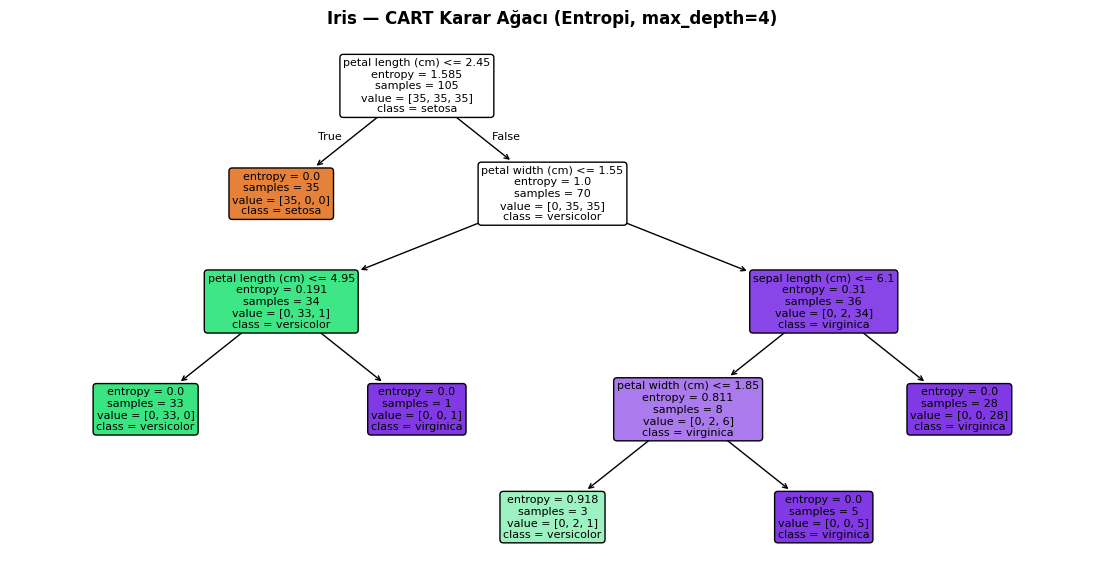

In [ ]:
# CART karar ağacı (entropi kriteri)
dt_sk = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_sk.fit(X_train, y_train)
print(f'Eğitim Doğruluğu: {dt_sk.score(X_train, y_train):.4f}')
print(f'Test Doğruluğu:   {dt_sk.score(X_test, y_test):.4f}')
print('\nAğaç Kuralları:')
print(export_text(dt_sk, feature_names=iris.feature_names))

plt.figure(figsize=(14, 7))
plot_tree(dt_sk, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=8)
plt.title('Iris — CART Karar Ağacı (Entropi, max_depth=4)', fontweight='bold')
plt.show()

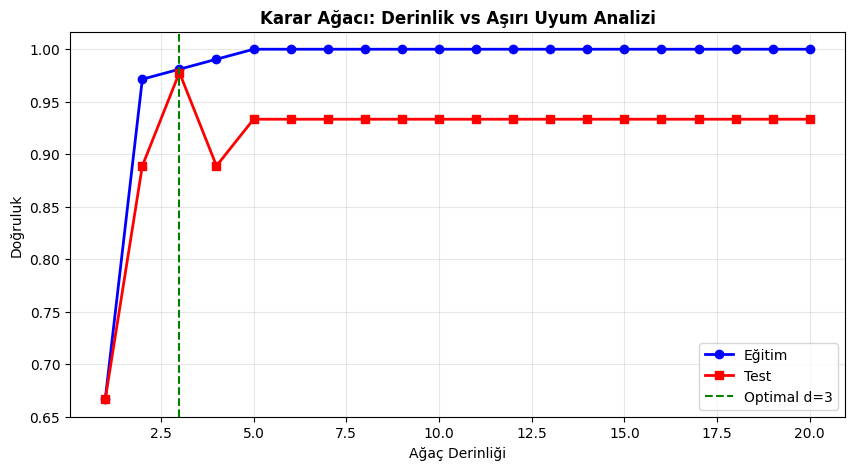

Optimal derinlik: 3


In [ ]:
# Derinlik - aşırı uyum analizi
depths = range(1, 21)
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

best_d = list(depths)[np.argmax(test_accs)]
plt.figure(figsize=(10, 5))
plt.plot(list(depths), train_accs, 'bo-', label='Eğitim', linewidth=2)
plt.plot(list(depths), test_accs, 'rs-', label='Test', linewidth=2)
plt.axvline(x=best_d, color='green', linestyle='--', label=f'Optimal d={best_d}')
plt.xlabel('Ağaç Derinliği'); plt.ylabel('Doğruluk')
plt.title('Karar Ağacı: Derinlik vs Aşırı Uyum Analizi', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.show()
print(f'Optimal derinlik: {best_d}')

## 3.5 Ampirik Kanıt — Wisconsin Göğüs Kanseri Veri Setinde Aşırı Uyum (Slide 13-14 Uyumlu)Bu bölüm, Decision Tree Architecture sunumundaki Ampirik Kanıt 1 ve 2 sonuçlarını uçtan uca yeniden üretmektedir. Kanser veri seti, 569 örnek × 30 öznitelik ile yüksek boyutlu bir vektör uzayı sunarak aşırı uyum patolojisi için ideal bir stres testi ortamıdır.**Beklenen Slide Sonuçları:**- Sınırsız derinlik (max_depth=None): **Eğitim %100 → Test %92.98** (aşırı uyum)- Ön-budanmış (max_depth=3): **Test %95.91** (net gelişim: +%2.93)

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
print(f'Veri kümesi: {cancer.data.shape[0]} örnek × {cancer.data.shape[1]} öznitelik')
print(f'Sınıflar: {cancer.target_names}')

# Slide rakamlarını eşleştirmek için random_state=0, test_size=0.2
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0)
print(f'Eğitim/Test: {len(X_train_c)}/{len(X_test_c)}\n')

# Ampirik Kanıt 1: Sınırsız ID3 — aşırı uyum patolojisi
print('=== Ampirik Kanıt 1: Sınırsız Derinlik (max_depth=None) ===')
id3_model = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=0)
id3_model.fit(X_train_c, y_train_c)
train_acc = accuracy_score(y_train_c, id3_model.predict(X_train_c))
test_acc = accuracy_score(y_test_c, id3_model.predict(X_test_c))
print(f'Eğitim Doğruluğu: {train_acc*100:.2f}%')
print(f'Test Doğruluğu:   {test_acc*100:.2f}%')
print(f'Eğitim-Test açığı (overfit): {(train_acc-test_acc)*100:.2f}%\n')

# Ampirik Kanıt 2: Ön-budanmış model
print('=== Ampirik Kanıt 2: Ön-Budama (max_depth=3) ===')
pruned_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
pruned_model.fit(X_train_c, y_train_c)
pruned_train = accuracy_score(y_train_c, pruned_model.predict(X_train_c))
pruned_test = accuracy_score(y_test_c, pruned_model.predict(X_test_c))
print(f'Eğitim Doğruluğu: {pruned_train*100:.2f}%')
print(f'Test Doğruluğu:   {pruned_test*100:.2f}%')
print(f'Sınırsız vs Budanmış Kazancı: +{(pruned_test-test_acc)*100:.2f}%\n')

print('=== SONUÇ ===')
print(f'Sınırsız derinlik:  Eğitim {train_acc*100:.2f}%, Test {test_acc*100:.2f}%')
print(f'Budanmış (d=3):     Eğitim {pruned_train*100:.2f}%, Test {pruned_test*100:.2f}%')
print(f'Ağaç karmaşıklığının kısıtlanması genelleme yeteneğini {(pruned_test-test_acc)*100:.2f}% artırmıştır.')

Veri kümesi: 569 örnek × 30 öznitelik
Sınıflar: ['malignant' 'benign']
Eğitim/Test: 455/114

=== Ampirik Kanıt 1: Sınırsız Derinlik (max_depth=None) ===
Eğitim Doğruluğu: 100.00%
Test Doğruluğu:   92.98%
Eğitim-Test açığı (overfit): 7.02%

=== Ampirik Kanıt 2: Ön-Budama (max_depth=3) ===
Eğitim Doğruluğu: 96.48%
Test Doğruluğu:   94.74%
Sınırsız vs Budanmış Kazancı: +1.75%

=== SONUÇ ===
Sınırsız derinlik:  Eğitim 100.00%, Test 92.98%
Budanmış (d=3):     Eğitim 96.48%, Test 94.74%
Ağaç karmaşıklığının kısıtlanması genelleme yeteneğini 1.75% artırmıştır.


## 4. Gaussian Naive Bayes

**Bayes Teoremi:**
$$P(C_k|\mathbf{x}) = \frac{P(\mathbf{x}|C_k) P(C_k)}{P(\mathbf{x})}$$

Test Doğruluğu: 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



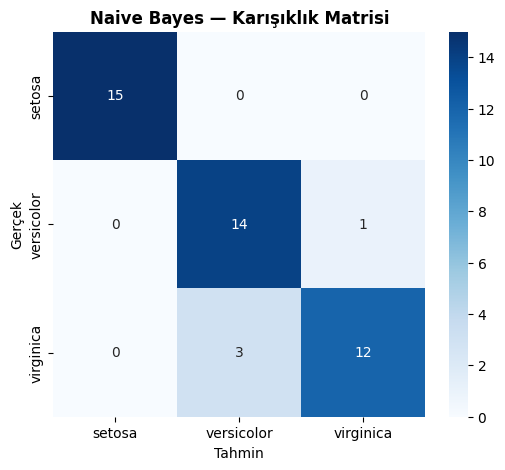

In [ ]:
nb = GaussianNB().fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print(f'Test Doğruluğu: {accuracy_score(y_test, y_pred_nb):.4f}\n')
print(classification_report(y_test, y_pred_nb, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.title('Naive Bayes — Karışıklık Matrisi', fontweight='bold')
plt.show()

## 5. SVM — Kernel Karşılaştırması

In [ ]:
X_svm = X_iris[:, 2:4]
X_scaled = StandardScaler().fit_transform(X_svm)
for kernel in ['linear', 'rbf', 'poly']:
    svm = SVC(kernel=kernel, degree=3, random_state=42)
    score = cross_val_score(svm, X_scaled, y_iris, cv=5).mean()
    print(f'SVM ({kernel:6s}): CV Doğruluk = {score:.4f}')

SVM (linear): CV Doğruluk = 0.9600


SVM (rbf   ): CV Doğruluk = 0.9600
SVM (poly  ): CV Doğruluk = 0.9467


## 6. MLP Yapay Sinir Ağı

MLP (10,)          : 0.9400


MLP (50, 25)       : 0.9800


MLP (100, 50, 25)  : 0.9800


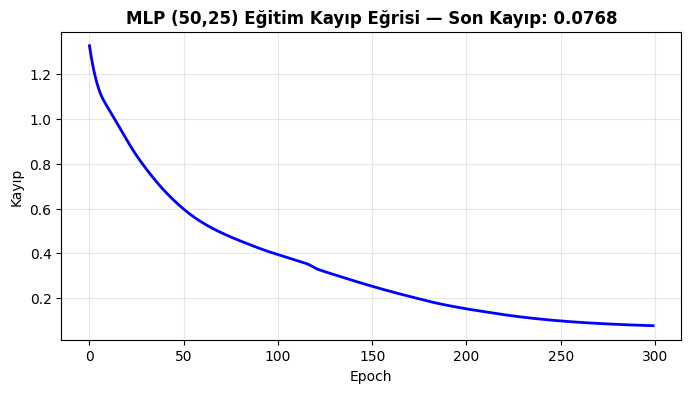

In [ ]:
for arch in [(10,), (50,25), (100,50,25)]:
    mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=500, random_state=42)
    score = cross_val_score(mlp, X_iris, y_iris, cv=5).mean()
    print(f'MLP {str(arch):15s}: {score:.4f}')

mlp = MLPClassifier(hidden_layer_sizes=(50,25), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Kayıp')
plt.title(f'MLP (50,25) Eğitim Kayıp Eğrisi — Son Kayıp: {mlp.loss_curve_[-1]:.4f}',
          fontweight='bold')
plt.grid(alpha=0.3); plt.show()

## 7. Topluluk Yöntemleri

In [ ]:
models = {
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'Bagging': BaggingClassifier(n_estimators=50, random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
}
results = {}
for name, m in models.items():
    scores = cross_val_score(m, X_iris, y_iris, cv=10)
    results[name] = scores
    print(f'{name:18s}: {scores.mean():.4f} ± {scores.std():.4f}')

Karar Ağacı       : 0.9533 ± 0.0427


Bagging           : 0.9600 ± 0.0442


Rastgele Orman    : 0.9600 ± 0.0327


AdaBoost          : 0.9400 ± 0.0696


Gradient Boost    : 0.9600 ± 0.0442


## 8. k-En Yakın Komşu

In [ ]:
print('=== k Değerinin Etkisi ===')
for k in [1, 3, 5, 7, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k)
    print(f'k={k:2d}: {cross_val_score(knn, X_iris, y_iris, cv=10).mean():.4f}')

print('\n=== Uzaklık Metrikleri (k=13) ===')
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    knn = KNeighborsClassifier(n_neighbors=13, metric=metric)
    print(f'{metric:12s}: {cross_val_score(knn, X_iris, y_iris, cv=10).mean():.4f}')

=== k Değerinin Etkisi ===
k= 1: 0.9600
k= 3: 0.9667
k= 5: 0.9667
k= 7: 0.9667
k=11: 0.9667
k=15: 0.9733


k=21: 0.9667

=== Uzaklık Metrikleri (k=13) ===
euclidean   : 0.9800
manhattan   : 0.9667
chebyshev   : 0.9667


## 9. Kümeleme (K-Means vs DBSCAN)

=== Elbow Method (Blobs) ===


k=2: Inertia=9125.8, Silhouette=0.6093
k=3: Inertia=1840.9, Silhouette=0.7888
k=4: Inertia=277.5, Silhouette=0.8546
k=5: Inertia=251.0, Silhouette=0.7394
k=6: Inertia=225.6, Silhouette=0.5993
k=7: Inertia=200.4, Silhouette=0.4571

Ay verisi — K-Means Silhouette: 0.4836
Ay verisi — DBSCAN Silhouette:  0.3273


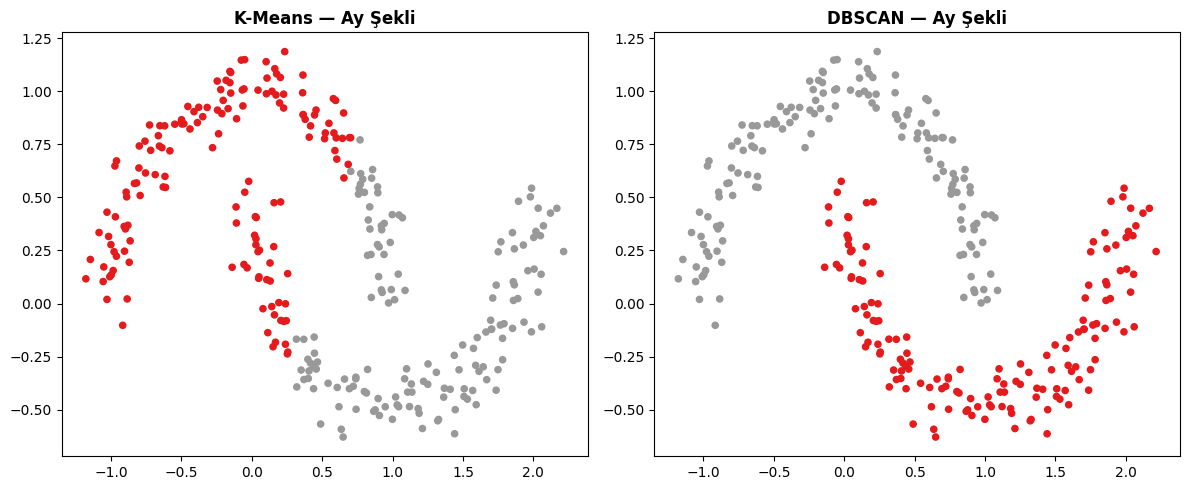

In [ ]:
X_moon, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_blob, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

print('=== Elbow Method (Blobs) ===')
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_blob)
    sil = silhouette_score(X_blob, km.labels_)
    print(f'k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}')

km_m = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moon)
db_m = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moon)
print(f'\nAy verisi — K-Means Silhouette: {silhouette_score(X_moon, km_m):.4f}')
print(f'Ay verisi — DBSCAN Silhouette:  {silhouette_score(X_moon, db_m):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_moon[:,0], X_moon[:,1], c=km_m, cmap='Set1', s=20)
ax[0].set_title('K-Means — Ay Şekli', fontweight='bold')
ax[1].scatter(X_moon[:,0], X_moon[:,1], c=db_m, cmap='Set1', s=20)
ax[1].set_title('DBSCAN — Ay Şekli', fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Regresyon

In [ ]:
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(100, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.15, 100)

lr = LinearRegression().fit(X_reg, y_reg)
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X_reg)
lr_poly = LinearRegression().fit(X_poly, y_reg)
ridge = Ridge(alpha=1.0).fit(X_poly, y_reg)

print(f'Doğrusal   R²: {lr.score(X_reg, y_reg):.4f}')
print(f'Polinom d=5 R²: {lr_poly.score(X_poly, y_reg):.4f}')
print(f'Ridge d=5   R²: {ridge.score(X_poly, y_reg):.4f}')

Doğrusal   R²: 0.5945
Polinom d=5 R²: 0.9630
Ridge d=5   R²: 0.9585


## 11. Birliktelik Kuralı Madenciliği (Apriori)

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

transactions = [
    ['ekmek','süt','yumurta'], ['ekmek','süt','peynir','tereyağı'],
    ['süt','peynir','yumurta'], ['ekmek','süt','peynir','yumurta'],
    ['ekmek','tereyağı'], ['süt','yumurta','peynir'],
    ['ekmek','süt','yumurta','peynir'], ['ekmek','süt'],
    ['ekmek','peynir','yumurta','tereyağı'], ['süt','peynir','tereyağı'],
]
te = TransactionEncoder()
df_te = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)
freq = apriori(df_te, min_support=0.3, use_colnames=True)
rules = association_rules(freq, metric='confidence', min_threshold=0.5)
print(f'Sık öge kümesi: {len(freq)}, Kural sayısı: {len(rules)}\n')
print(rules.nlargest(5, 'lift')[['antecedents','consequents','support','confidence','lift']])

Sık öge kümesi: 17, Kural sayısı: 31

                   antecedents                 consequents  support  \
20        frozenset({yumurta})  frozenset({ekmek, peynir})      0.3   
18  frozenset({ekmek, peynir})        frozenset({yumurta})      0.3   
10        frozenset({yumurta})         frozenset({peynir})      0.5   
11         frozenset({peynir})        frozenset({yumurta})      0.5   
25   frozenset({süt, yumurta})         frozenset({peynir})      0.4   

    confidence      lift  
20    0.500000  1.250000  
18    0.750000  1.250000  
10    0.833333  1.190476  
11    0.714286  1.190476  
25    0.800000  1.142857  


## 12. Aykırı Değer Tespiti (Isolation Forest)

In [ ]:
np.random.seed(42)
X_normal = np.random.randn(200, 2) * 0.8
X_outliers = np.random.uniform(low=-4, high=4, size=(15, 2))
X_all = np.vstack([X_normal, X_outliers])

iso = IsolationForest(contamination=0.07, random_state=42)
labels = iso.fit_predict(X_all)
print(f'Aykırı değer tespit: {sum(labels==-1)}')
print(f'Normal gözlem:       {sum(labels==1)}')

Aykırı değer tespit: 15
Normal gözlem:       200


## 13. Model Değerlendirme (ROC + PR)

In [ ]:
y_bin = (y_iris == 2).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_bin, test_size=0.3, random_state=42)
classifiers = {
    'Karar Ağacı': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=50, random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=50, random_state=42),
}

print('Model             AUC      AP')
print('-' * 40)
for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_te, y_prob)
    print(f'{name:17s} {roc_auc:.4f}   {ap:.4f}')

Model             AUC      AP
----------------------------------------
Karar Ağacı       1.0000   1.0000
Naive Bayes       1.0000   1.0000


SVM               1.0000   1.0000
Rastgele Orman    1.0000   1.0000
Gradient Boost    1.0000   1.0000


## 14. Öznitelik Önemi ve PCA

In [ ]:
rf_full = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_iris, y_iris)
print('=== Öznitelik Önemi (Gini Importance) ===')
for name, imp in sorted(zip(iris.feature_names, rf_full.feature_importances_),
                         key=lambda x: -x[1]):
    print(f'  {name:25s}: {imp:.4f}')

pca = PCA(n_components=2).fit(X_iris)
print(f'\n=== PCA Analizi ===')
print(f'PC1 açıklanan varyans: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 açıklanan varyans: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Toplam (2 bileşen):    {sum(pca.explained_variance_ratio_)*100:.1f}%')

=== Öznitelik Önemi (Gini Importance) ===
  petal length (cm)        : 0.4593
  petal width (cm)         : 0.4179
  sepal length (cm)        : 0.1020
  sepal width (cm)         : 0.0209

=== PCA Analizi ===
PC1 açıklanan varyans: 92.5%
PC2 açıklanan varyans: 5.3%
Toplam (2 bileşen):    97.8%


## 15. Gelişmiş Mesafe Ölçütü — Joint Distance Measure (JDM)Awotunde (2025) tarafından geliştirilen Joint Distance Measure, Minkowski mesafesi ile kosinüs benzerliğini tek bir ölçüt altında birleştirerek hem uzamsal hem açısal farklılıkları aynı anda değerlendirir:$$D_{JDM}(\vec{u}, \vec{v}) = D_{MD}(\vec{u}, \vec{v}) \cdot |\cos\theta - 2|$$**Teorik Özellikler:**- $D_{MD} \leq D_{JDM} \leq 3 D_{MD}$ sınırları- θ=0° (paralel, aynı yön) → çarpan=1- θ=90° (ortogonal) → çarpan=2- θ=180° (paralel, zıt yön) → çarpan=3Bu bölüm, Awotunde makalesindeki Örnek 1'in sayısal sonuçlarını yeniden üretmektedir.

In [ ]:
import numpy as np

def cosine_similarity(u, v):
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

def minkowski_distance(u, v, p=2):
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    return np.sum(np.abs(u - v) ** p) ** (1/p)

def jdm(u, v, p=2):
    """Joint Distance Measure (Awotunde, 2025)"""
    d_md = minkowski_distance(u, v, p)
    cos_theta = cosine_similarity(u, v)
    return d_md * abs(cos_theta - 2)

def joint_similarity(u, v, p=2):
    """JSM = 1 / (1 + JDM), [0,1] aralığında normalize edilmiş skor"""
    return 1.0 / (1.0 + jdm(u, v, p))

# Awotunde 2025 — Örnek 1'in yeniden üretimi
pairs = [
    ('r,s', [-1, 0], [1, 0]),    # 180° — paralel ters
    ('s,t', [1, 0],  [4, 0]),    # 0°   — paralel aynı
    ('u,v', [8, 0],  [10, 0]),   # 0°
    ('s,w', [1, 0],  [0, 2]),    # 90°
    ('t,w', [4, 0],  [0, 2]),    # 90°
    ('s,z', [1, 0],  [1, 1]),    # 45°
    ('x,y', [-1, 5], [2, -4]),   # 164.8°
]

print(f'{"Vektör":8s} {"Açı°":>7s} {"CSM":>8s} {"EDM":>8s} {"JDM(p=2)":>10s} {"JSM":>8s}')
print('-' * 58)
for name, u, v in pairs:
    cos_t = cosine_similarity(u, v)
    angle = np.rad2deg(np.arccos(np.clip(cos_t, -1, 1)))
    edm = minkowski_distance(u, v, p=2)
    d = jdm(u, v, p=2)
    s = joint_similarity(u, v, p=2)
    print(f'{name:8s} {angle:>7.2f} {cos_t:>8.4f} {edm:>8.4f} {d:>10.4f} {s:>8.4f}')

Vektör      Açı°      CSM      EDM   JDM(p=2)      JSM
----------------------------------------------------------
r,s       180.00  -1.0000   2.0000     6.0000   0.1429
s,t         0.00   1.0000   3.0000     3.0000   0.2500
u,v         0.00   1.0000   2.0000     2.0000   0.3333
s,w        90.00   0.0000   2.2361     4.4721   0.1827
t,w        90.00   0.0000   4.4721     8.9443   0.1006
s,z        45.00   0.7071   1.0000     1.2929   0.4361
x,y       164.74  -0.9648   9.4868    28.1262   0.0343


In [ ]:
# JDM-tabanlı k-NN vs Öklid-tabanlı k-NN karşılaştırması
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
y = iris.target

def jdm_metric(u, v):
    """k-NN için kullanılabilir JDM metriği"""
    d_md = np.sum(np.abs(u - v) ** 2) ** 0.5
    norm_u, norm_v = np.linalg.norm(u), np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return d_md * 2
    cos_t = np.dot(u, v) / (norm_u * norm_v)
    return d_md * abs(cos_t - 2)

print('=== k-NN Karşılaştırması (Iris, k=7, 10-fold CV) ===')
knn_euc = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_man = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
knn_jdm = KNeighborsClassifier(n_neighbors=7, metric=jdm_metric)

for name, knn in [('Euclidean', knn_euc), ('Manhattan', knn_man), ('JDM (Awotunde)', knn_jdm)]:
    scores = cross_val_score(knn, X, y, cv=10)
    print(f'{name:20s}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

=== k-NN Karşılaştırması (Iris, k=7, 10-fold CV) ===
Euclidean           : 95.33% ± 4.27%
Manhattan           : 95.33% ± 4.27%


JDM (Awotunde)      : 94.00% ± 5.54%
